# Ячейка 1: Импорты и настройка среды

In [9]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          pipeline)
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

# Фиксация Seed
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Ячейка 2: Загрузка и анализ данных


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры текстов:


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


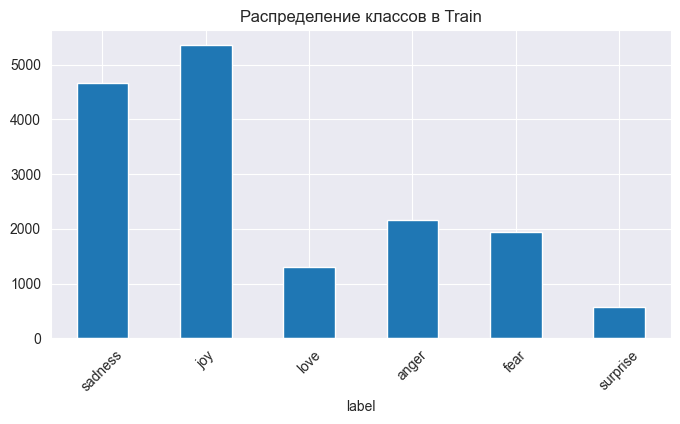

In [10]:
# Загружаем датасет emotion (классификация эмоций: sadness, joy, love, anger, fear, surprise)
dataset = load_dataset("dair-ai/emotion")

print(dataset)

# Названия классов
labels = dataset["train"].features["label"].names
num_labels = len(labels)
print(f"Labels: {labels}")

# Примеры данных
df_train = dataset["train"].to_pandas()
print("\nПримеры текстов:")
display(df_train.head())

# Проверка баланса
plt.figure(figsize=(8, 4))
df_train['label'].value_counts().sort_index().plot(kind='bar')
plt.title("Распределение классов в Train")
plt.xticks(range(num_labels), labels, rotation=45)
plt.show()

# Ячейка 3: Разбор токенизации


In [11]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

sample_texts = df_train["text"].iloc[:3].tolist()

print(f"Модель токенизатора: {model_checkpoint}")
print(f"Special tokens: {tokenizer.all_special_tokens} (IDs: {tokenizer.all_special_ids})")

for text in sample_texts:
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.encode(text)
    print(f"\nТекст: {text}")
    print(f"Токены: {tokens}")
    print(f"IDs: {ids}")

# Демонстрация padding и truncation
encoded = tokenizer(sample_texts, padding=True, truncation=True, max_length=16, return_tensors="pt")
print("\nPadding/Truncation example (max_length=16):")
print(f"Shape: {encoded['input_ids'].shape}")
print(encoded['input_ids'])

Модель токенизатора: distilbert-base-uncased
Special tokens: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]'] (IDs: [100, 102, 0, 101, 103])

Текст: i didnt feel humiliated
Токены: ['i', 'didn', '##t', 'feel', 'humiliated']
IDs: [101, 1045, 2134, 2102, 2514, 26608, 102]

Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake']
IDs: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]

Текст: im grabbing a minute to post i feel greedy wrong
Токены: ['im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong']
IDs: [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20505, 3308, 102]

Padding/Truncation example (max_length=16):
Shape: torch.Size([3

# Ячейка 4: Инференс готовой модели (Zero-shot или Sentiment)


In [12]:
# Возьмем модель, предобученную на анализ тональности (2 класса),
# чтобы посмотреть, как она справится с 6 эмоциями
sentiment_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=device)

print("Инференс готовой модели (SST-2) на наших данных:")
for i in range(5):
    text = dataset["test"][i]["text"]
    true_label = labels[dataset["test"][i]["label"]]
    pred = sentiment_pipe(text)[0]
    print(f"Текст: {text[:60]}...")
    print(f"True: {true_label} | Pred: {pred['label']} (conf: {pred['score']:.3f})\n")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8666.78it/s]


Инференс готовой модели (SST-2) на наших данных:
Текст: im feeling rather rotten so im not very ambitious right now...
True: sadness | Pred: NEGATIVE (conf: 1.000)

Текст: im updating my blog because i feel shitty...
True: sadness | Pred: NEGATIVE (conf: 0.999)

Текст: i never make her separate from me because i don t ever want ...
True: sadness | Pred: POSITIVE (conf: 0.999)

Текст: i left with my bouquet of red and yellow tulips under my arm...
True: joy | Pred: POSITIVE (conf: 0.987)

Текст: i was feeling a little vain when i did this one...
True: sadness | Pred: NEGATIVE (conf: 1.000)



# Ячейка 5: Подготовка к Fine-tuning


In [13]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels)
model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5880.88it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Ячейка 6: Обучение

In [17]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.195163,0.177866,0.931000,0.904557
2,0.098454,0.154373,0.938500,0.910562


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.90it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2000, training_loss=0.17321292686462403, metrics={'train_runtime': 255.9528, 'train_samples_per_second': 125.023, 'train_steps_per_second': 7.814, 'total_flos': 690100881209280.0, 'train_loss': 0.17321292686462403, 'epoch': 2.0})

# Ячейка 7: Оценка и Артефакты


Test Metrics: {'test_loss': 0.1797969937324524, 'test_accuracy': 0.928, 'test_f1_macro': 0.8860322781059603, 'test_runtime': 2.7047, 'test_samples_per_second': 739.456, 'test_steps_per_second': 46.216}


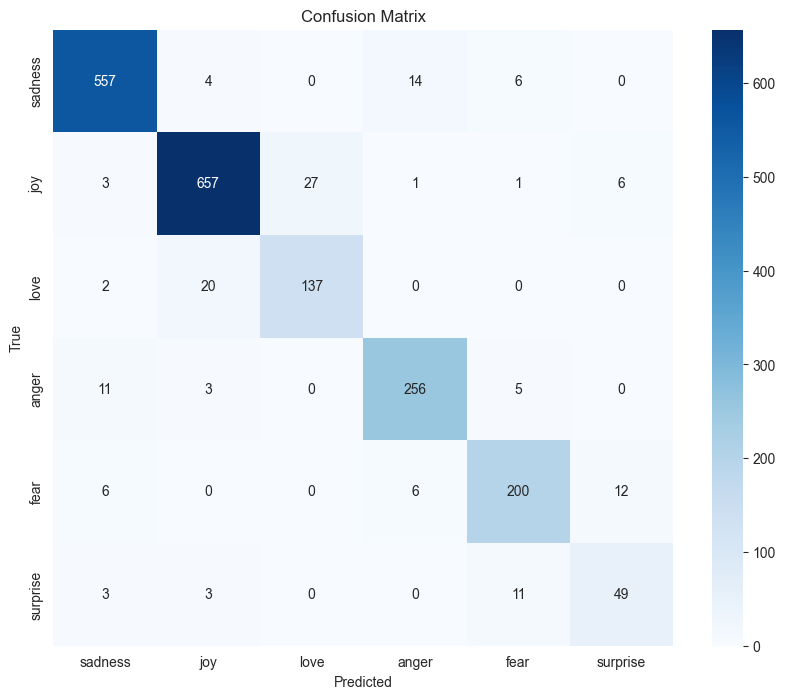


Примеры ошибок:


,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.892538
67,i feel a bit stressed even though all the thin...,anger,sadness,0.522868
72,i am right handed however i play billiards lef...,surprise,fear,0.618882
86,i feel like i am in paradise kissing those swe...,joy,love,0.756468
93,i was feeling weird the other day and it went ...,fear,surprise,0.522824


In [19]:
# Финальная оценка на test
test_results = trainer.predict(tokenized_datasets["test"])
print(f"Test Metrics: {test_results.metrics}")

preds = np.argmax(test_results.predictions, axis=-1)
true_labels = test_results.label_ids

# Сохранение матрицы ошибок
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('artifacts/confusion_matrix.png')
plt.show()

# Сохранение предсказаний
test_texts = dataset["test"]["text"]
probs = torch.nn.functional.softmax(torch.from_numpy(test_results.predictions), dim=-1)
confidences = torch.max(probs, dim=-1).values.numpy()

results_df = pd.DataFrame({
    'text': test_texts,
    'true_label': [labels[i] for i in true_labels],
    'pred_label': [labels[i] for i in preds],
    'confidence': confidences
})
results_df.to_csv('artifacts/sample_predictions.csv', index=False)

# Анализ ошибок
errors = results_df[results_df['true_label'] != results_df['pred_label']]
print("\nПримеры ошибок:")
display(errors.head(5))